# Apply `policlim` to Colombian manifestos: 2022 and 2026

This notebook collects the presidential manifesto PDFs for the **2022** and **2026** elections, extracts their text, classifies sentence-level text with [`marysanford/policlim`](https://huggingface.co/marysanford/policlim), and reports manifesto-level climate-salience shares.

The two election years are processed and stored **separately** (`output/manifestos/policlim_2022/` and `.../policlim_2026/`). They are pooled only in the final comparison section, so that candidates can be compared within a year and across years on a common scale.

PDFs are read only from the local folder `data/manifestos/raw/<year>/`. Nothing is downloaded: the files on disk are the corpus, so adding, replacing or removing a PDF there is the only way to change what is analysed.

A candidate's programme may be published as several PDFs. Files whose names resolve to the same entry in `MANIFESTO_META` are merged into one document before classification, so each candidate contributes a single manifesto-level share; the constituent filenames are kept in the `source_files` column.

The model was developed for political manifesto text. Its authors recommend manually validating samples of predictions, especially when applying it to a new source or language.

In [61]:
%pip install -q pandas pypdf torch transformers

Note: you may need to restart the kernel to use updated packages.


In [62]:
from pathlib import Path
import json
import re
import unicodedata

import pandas as pd
from pypdf import PdfReader
from transformers import pipeline

NOTEBOOK_NAME = "apply_policlim_to_manifestos_2022_2026.ipynb"

# VS Code may start the notebook kernel outside the project directory.
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / NOTEBOOK_NAME).exists():
    notebook_project = Path.home() / "Dropbox" / "Green_Backlash_Colombia"
    if (notebook_project / NOTEBOOK_NAME).exists():
        PROJECT_ROOT = notebook_project

# The two election years are kept in separate folders throughout; they are pooled
# only in the comparison section at the end of the notebook.
YEARS = ["2022", "2026"]

RAW_ROOT = PROJECT_ROOT / "data" / "manifestos" / "raw"
OUTPUT_ROOT = PROJECT_ROOT / "output" / "manifestos"
PDF_DIRS = {year: RAW_ROOT / year for year in YEARS}
OUTPUT_DIRS = {year: OUTPUT_ROOT / f"policlim_{year}" for year in YEARS}
COMPARISON_DIR = OUTPUT_ROOT / "policlim_comparison"
for directory in [*PDF_DIRS.values(), *OUTPUT_DIRS.values(), COMPARISON_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_ID = "marysanford/policlim"

print(f"Project root: {PROJECT_ROOT}")
for year in YEARS:
    print(f"{year}: PDFs in {PDF_DIRS[year]} -> outputs in {OUTPUT_DIRS[year]}")
print(f"Cross-year comparison outputs: {COMPARISON_DIR}")

Project root: /home/charlott/Dropbox/Green_Backlash_Colombia
2022: PDFs in /home/charlott/Dropbox/Green_Backlash_Colombia/data/manifestos/raw/2022 -> outputs in /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_2022
2026: PDFs in /home/charlott/Dropbox/Green_Backlash_Colombia/data/manifestos/raw/2026 -> outputs in /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_2026
Cross-year comparison outputs: /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_comparison


In [63]:
def collect_year(year):
    """Return one record per PDF found locally for `year`.

    The local folder is the single source of truth: nothing is fetched from a remote
    repository, so the corpus is exactly what sits in `data/manifestos/raw/<year>/`.
    """
    return [
        {
            "year": year,
            "filename": pdf_path.name,
            "local_path": str(pdf_path),
            "size_bytes": pdf_path.stat().st_size,
            "modified": pd.Timestamp(pdf_path.stat().st_mtime, unit="s").strftime("%Y-%m-%d %H:%M"),
        }
        for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf"))
    ]


file_manifest = [record for year in YEARS for record in collect_year(year)]
manifest_df = pd.DataFrame(file_manifest)
if manifest_df.empty:
    raise FileNotFoundError(f"No PDFs found for years {YEARS} under {RAW_ROOT}")

# Zero-byte files would silently contribute no sentences; flag them rather than skip them.
empty_files = manifest_df[manifest_df["size_bytes"] == 0]
if not empty_files.empty:
    print("Empty PDF file(s) - remove or replace them:")
    print(empty_files[["year", "filename"]].to_string(index=False), "\n")

for year in YEARS:
    count = int((manifest_df["year"] == year).sum())
    print(f"{year}: {count} manifesto PDF(s) in {PDF_DIRS[year]}")
    if count == 0:
        print(f"  -> place the {year} PDFs there and re-run this cell")

manifest_df


2022: 4 manifesto PDF(s) in /home/charlott/Dropbox/Green_Backlash_Colombia/data/manifestos/raw/2022
2026: 6 manifesto PDF(s) in /home/charlott/Dropbox/Green_Backlash_Colombia/data/manifestos/raw/2026


,year,filename,local_path,size_bytes,modified
0,2022,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,3337256,2026-08-29 11:22
1,2022,Programa-de-gobierno-Gustavo-Petro-2022-–-2026...,/home/charlott/Dropbox/Green_Backlash_Colombia...,8587694,2026-08-29 11:18
2,2022,RodolfoHernandez-ProgramaDeGobierno.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,6547840,2026-08-29 11:19
3,2022,resumen-propuestas-sergio-fajardo.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,7380797,2026-08-29 11:26
4,2026,Claudia-lopez-Programa-Gobierno-nueva-historia...,/home/charlott/Dropbox/Green_Backlash_Colombia...,4630919,2026-08-28 11:44
5,2026,PROPUESTAS_de_la_Espriella.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,1851004,2026-08-28 11:44
6,2026,Plan Integrado de Gobierno Final_compressed.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,171568,2026-08-28 11:44
7,2026,Programa-Dignidad-Compromiso.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,311314,2026-08-28 11:44
8,2026,Programa_de_gobierno_Abelardo_de_la_Espriella_...,/home/charlott/Dropbox/Green_Backlash_Colombia...,2885602,2026-08-31 14:43
9,2026,programa-gobierno-2026-2030_cepeda.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,11770787,2026-08-31 14:50


In [64]:
def clean_text(text):
    text = unicodedata.normalize("NFC", text or "")
    text = text.replace("\x00", " ")
    return re.sub(r"\s+", " ", text).strip()


# Some PDFs store text as Latin-1 bytes while declaring Adobe StandardEncoding, so every
# accented character extracts as an unrelated glyph: "climática" arrives as "climÆtica".
# Accent stripping cannot normalise these, so the keyword counts would silently miss any
# term spelled with á or é. The Windows-1252 quotes and dashes are undecoded in the same
# documents and are repaired here too, because the sentence splitter keys on punctuation.
STANDARD_ENCODING_REPAIRS = {
    "Æ": "á", "Ø": "é", "œ": "ú", "æ": "ñ", "˝": "Í", "`": "Á",
    "\x93": "\u201c", "\x94": "\u201d", "\x96": "\u2013", "\x97": "\u2014",
}
_REPAIR_TABLE = str.maketrans(STANDARD_ENCODING_REPAIRS)
_REPAIR_MIN_RATE = 1e-4  # ~1 affected glyph per 10,000 characters


def repair_encoding(text):
    """Undo StandardEncoding mis-decoding, but only in documents that clearly show it.

    The substitutions are applied per document rather than unconditionally, so that an
    isolated legitimate "Ø" or backtick in an unaffected manifesto is left as it is.
    """
    if not text:
        return text
    hits = sum(text.count(glyph) for glyph in STANDARD_ENCODING_REPAIRS)
    if hits / len(text) < _REPAIR_MIN_RATE:
        return text
    return text.translate(_REPAIR_TABLE)

def extract_pdf_text(pdf_path):
    reader = PdfReader(str(pdf_path))
    page_text = [clean_text(page.extract_text()) for page in reader.pages]
    # The repair decision is taken on the whole document: single pages are too short for
    # the glyph rate to be a reliable signal.
    document_text = repair_encoding(clean_text(" ".join(page_text)))
    return document_text, len(reader.pages), sum(bool(text) for text in page_text)
 
def split_into_sentences(text):
    # A lightweight splitter keeps the notebook self-contained and works for Spanish punctuation.
    candidates = re.split(r"(?<=[.!?])\s+(?=[A-ZÁÉÍÓÚÜÑ¿¡0-9])|[\r\n]+", text)
    return [sentence.strip() for sentence in candidates if len(sentence.split()) >= 3]

def split_long_sentence(sentence, max_words=350):
    words = sentence.split()
    return [" ".join(words[start:start + max_words]) for start in range(0, len(words), max_words)]


# Map filenames to readable candidate labels and a coarse left-right placement.
# Keys are case-insensitive regexes matched against the filename, so the 2022 entries
# work regardless of the exact filenames used for those PDFs. Unmatched files keep
# their filename stem and are marked "Unclassified" rather than silently mislabelled.
#
# The label is also the merge key: when a candidate's programme is published as more
# than one PDF, every file matching the same pattern is treated as one manifesto.
MANIFESTO_META = [
    # 2026
    (r"programa-gobierno-2026-2030", "Pacto Histórico (Petro's party)", "Left"),
    (r"Programa-Dignidad-Compromiso", "Dignidad y Compromiso", "Left"),
    (r"claudia.?l[oó]pez", "Claudia López", "Center/independent"),
    (r"tigre|espriella", "De la Espriella", "Right"),
    (r"Plan Integrado de Gobierno", "Plan Integrado de Gobierno", "Right"),
    # 2022
    (r"petro|pacto.?hist", "Petro (Pacto Histórico)", "Left"),
    (r"fajardo|centro.?esperanza", "Fajardo (Centro Esperanza)", "Center/independent"),
    (r"betancourt|ox[ií]geno", "Betancourt (Verde Oxígeno)", "Center/independent"),
    (r"guti[eé]rrez|\bfico\b|equipo.?por.?colombia", "Gutiérrez (Equipo por Colombia)", "Right"),
    (r"hern[aá]ndez|rodolfo|liga", "Hernández (Liga Anticorrupción)", "Right"),
    (r"g[oó]mez|salvaci[oó]n", "Gómez (Salvación Nacional)", "Right"),
    (r"john.?milton|justa.?libres", "Rodríguez (Colombia Justa Libres)", "Right"),
]


def match_meta(filename):
    """Return (display label, ideological bloc) for a manifesto filename."""
    for pattern, label, position in MANIFESTO_META:
        if re.search(pattern, filename, flags=re.IGNORECASE):
            return label, position
    return Path(filename).stem, "Unclassified"


In [65]:
# One manifesto can be published as several PDFs. Files whose names resolve to the same
# label in MANIFESTO_META are merged into one document here, before classification, so
# that the manifesto-level share is computed over the candidate's whole programme rather
# than once per file. Sentences are split within each PDF first and only then
# concatenated, so the end of one file is never glued to the start of the next.
# Files are concatenated in filename order; the originating PDF stays in
# `manifesto_file`, so every sentence remains traceable to its source.
sentence_rows = []
sentence_counters = {}
for year in YEARS:
    for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf")):
        manifesto_id, position = match_meta(pdf_path.name)
        text, page_count, pages_with_text = extract_pdf_text(pdf_path)
        expanded_sentences = []
        for sentence in split_into_sentences(text):
            expanded_sentences.extend(split_long_sentence(sentence))

        if not expanded_sentences:
            # Scanned PDFs return no embedded text; they need OCR before they can be scored.
            print(
                f"WARNING {year}/{pdf_path.name}: no text extracted "
                f"({page_count} pages, {pages_with_text} with text) - likely a scanned PDF requiring OCR"
            )

        key = (year, manifesto_id)
        for sentence in expanded_sentences:
            # Sentence numbers run continuously across the files of a merged manifesto.
            sentence_counters[key] = sentence_counters.get(key, 0) + 1
            sentence_rows.append({
                "year": year,
                "manifesto_id": manifesto_id,
                "position": position,
                "manifesto_file": pdf_path.name,
                "manifesto_source_path": str(pdf_path),
                "sentence_number": sentence_counters[key],
                "text": sentence,
            })

sentences_df = pd.DataFrame(sentence_rows)
if sentences_df.empty:
    raise ValueError(f"No sentences extracted from PDFs under {RAW_ROOT}")

# Report the merges explicitly: silently pooling two files would be easy to miss.
files_per_manifesto = sentences_df.groupby(["year", "manifesto_id"])["manifesto_file"].nunique()
merged = files_per_manifesto[files_per_manifesto > 1]
if merged.empty:
    print("No manifesto was assembled from more than one PDF.\n")
else:
    print("Manifestos merged from several PDFs:")
    for (year, manifesto_id), file_count in merged.items():
        parts = sorted(sentences_df.loc[
            (sentences_df["year"] == year) & (sentences_df["manifesto_id"] == manifesto_id),
            "manifesto_file",
        ].unique())
        print(f"  {year}  {manifesto_id}: {file_count} files -> {', '.join(parts)}")
    print()

extraction_overview = sentences_df.groupby("year").agg(
    manifestos=("manifesto_id", "nunique"),
    pdf_files=("manifesto_file", "nunique"),
    sentences=("text", "size"),
)
print(extraction_overview)
sentences_df.head()


Ignoring wrong pointing object 13 0 (offset 0)
Ignoring wrong pointing object 16 0 (offset 0)
Ignoring wrong pointing object 18 0 (offset 0)
Ignoring wrong pointing object 33 0 (offset 0)
Ignoring wrong pointing object 230 0 (offset 0)
Ignoring wrong pointing object 268 0 (offset 0)
Ignoring wrong pointing object 293 0 (offset 0)
Ignoring wrong pointing object 331 0 (offset 0)


Manifestos merged from several PDFs:
  2026  De la Espriella: 2 files -> PROPUESTAS_de_la_Espriella.pdf, Programa_de_gobierno_Abelardo_de_la_Espriella_2026_2030-1.pdf

      manifestos  pdf_files  sentences
year                                  
2022           4          4       2667
2026           5          6       2395


,year,manifesto_id,position,manifesto_file,manifesto_source_path,sentence_number,text
0,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,1,COLOMBIA: UN PAÍS EN ORDEN Y CON OPORTUNIDADES...
1,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,2,"OPORTUNIDADES para que todas las personas, sin..."
2,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,3,"Oportunidades de tener mejor educación, mejore..."
3,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,4,ORDEN Y OPORTUNIDADES para reducir la pobreza ...
4,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,5,Nuestro compromiso es liderar a Colombia desde...


In [66]:
# Load the published model. The model's config supplies the authoritative label names.
classifier = pipeline(
    task="text-classification",
    model=MODEL_ID,
    tokenizer=MODEL_ID,
    truncation=True,
    max_length=512,
    top_k=None,
)

id2label = classifier.model.config.id2label
print("Model labels:", id2label)

# Resolve the climate-relevant label once, from the config, rather than per sentence.
CLIMATE_LABEL = next(
    (label for label in id2label.values()
     if label.lower().endswith("1") or "climate" in label.lower() or "yes" in label.lower()),
    None,
)
if CLIMATE_LABEL is None:
    raise ValueError(f"Could not identify the climate-relevant label among {list(id2label.values())}")
print("Climate-relevant label:", CLIMATE_LABEL)


def normalise_predictions(batch_predictions):
    # Transformers versions differ slightly in their pipeline return shape.
    if batch_predictions and isinstance(batch_predictions[0], dict):
        batch_predictions = [batch_predictions]
    return batch_predictions


BATCH_SIZE = 32
texts = sentences_df["text"].tolist()
all_predictions = []
for start in range(0, len(texts), BATCH_SIZE):
    all_predictions.extend(
        normalise_predictions(classifier(texts[start:start + BATCH_SIZE], batch_size=BATCH_SIZE))
    )
    if (start // BATCH_SIZE) % 25 == 0:
        print(f"  classified {min(start + BATCH_SIZE, len(texts)):,}/{len(texts):,} sentences", end="\r")
print(f"  classified {len(all_predictions):,}/{len(texts):,} sentences")


def prediction_fields(predictions):
    by_label = {item["label"]: float(item["score"]) for item in predictions}
    top_label = max(by_label, key=by_label.get)
    return top_label, by_label[CLIMATE_LABEL], json.dumps(by_label, ensure_ascii=False)


fields = [prediction_fields(prediction) for prediction in all_predictions]
sentences_df[["predicted_label", "climate_score", "label_scores"]] = pd.DataFrame(fields, index=sentences_df.index)
sentences_df["climate_label"] = CLIMATE_LABEL
sentences_df["climate_relevant"] = sentences_df["predicted_label"] == CLIMATE_LABEL
sentences_df.head()

Device set to use cuda:0


Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}
Climate-relevant label: LABEL_1
  classified 5,062/5,062 sentences


,year,manifesto_id,position,manifesto_file,manifesto_source_path,sentence_number,text,predicted_label,climate_score,label_scores,climate_label,climate_relevant
0,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,1,COLOMBIA: UN PAÍS EN ORDEN Y CON OPORTUNIDADES...,LABEL_0,0.000975,"{""LABEL_0"": 0.9990249872207642, ""LABEL_1"": 0.0...",LABEL_1,False
1,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,2,"OPORTUNIDADES para que todas las personas, sin...",LABEL_0,0.001094,"{""LABEL_0"": 0.9989062547683716, ""LABEL_1"": 0.0...",LABEL_1,False
2,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,3,"Oportunidades de tener mejor educación, mejore...",LABEL_0,0.000898,"{""LABEL_0"": 0.9991017580032349, ""LABEL_1"": 0.0...",LABEL_1,False
3,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,4,ORDEN Y OPORTUNIDADES para reducir la pobreza ...,LABEL_0,0.000889,"{""LABEL_0"": 0.9991108775138855, ""LABEL_1"": 0.0...",LABEL_1,False
4,2022,Gutiérrez (Equipo por Colombia),Right,Creemos Colombia Federico Gutiérrez.pdf,/home/charlott/Dropbox/Green_Backlash_Colombia...,5,Nuestro compromiso es liderar a Colombia desde...,LABEL_0,0.001091,"{""LABEL_0"": 0.9989087581634521, ""LABEL_1"": 0.0...",LABEL_1,False


In [67]:
# MANIFESTO_META and match_meta are defined with the other helpers, above, because the
# extraction cell needs them to decide which PDFs belong to the same manifesto.
mapping_rows = []
for year in YEARS:
    for pdf_path in sorted(PDF_DIRS[year].glob("*.pdf")):
        label, position = match_meta(pdf_path.name)
        mapping_rows.append({
            "year": year,
            "position": position,
            "manifesto_id": label,
            "file": pdf_path.name,
        })

mapping_df = pd.DataFrame(mapping_rows)
print(f"{len(mapping_df)} PDF(s) -> {mapping_df[['year', 'manifesto_id']].drop_duplicates().shape[0]} manifesto(s)\n")
display(mapping_df.sort_values(["year", "manifesto_id", "file"]))

unmatched = mapping_df[mapping_df["position"] == "Unclassified"]
if not unmatched.empty:
    print("Files with no MANIFESTO_META entry - they are kept as separate manifestos:")
    print(unmatched[["year", "file"]].to_string(index=False))


10 PDF(s) -> 9 manifesto(s)



,year,position,manifesto_id,file
3,2022,Center/independent,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf
0,2022,Right,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf
2,2022,Right,Hernández (Liga Anticorrupción),RodolfoHernandez-ProgramaDeGobierno.pdf
1,2022,Left,Petro (Pacto Histórico),Programa-de-gobierno-Gustavo-Petro-2022-–-2026...
4,2026,Center/independent,Claudia López,Claudia-lopez-Programa-Gobierno-nueva-historia...
5,2026,Right,De la Espriella,PROPUESTAS_de_la_Espriella.pdf
8,2026,Right,De la Espriella,Programa_de_gobierno_Abelardo_de_la_Espriella_...
7,2026,Left,Dignidad y Compromiso,Programa-Dignidad-Compromiso.pdf
9,2026,Left,Pacto Histórico (Petro's party),programa-gobierno-2026-2030_cepeda.pdf
6,2026,Right,Plan Integrado de Gobierno,Plan Integrado de Gobierno Final_compressed.pdf


In [68]:
# Aggregate sentence predictions into the manifesto-level share used by policlim.
# The unit of aggregation is the manifesto, not the PDF: a programme split across
# several files contributes one row, with the source files listed for provenance.
summary_df = (
    sentences_df.groupby(["year", "manifesto_id", "position"], as_index=False)
    .agg(
        source_files=("manifesto_file", lambda names: "; ".join(sorted(set(names)))),
        source_documents=("manifesto_file", "nunique"),
        source_paths=("manifesto_source_path", lambda paths: "; ".join(sorted(set(paths)))),
        sentence_count=("text", "size"),
        climate_relevant_sentences=("climate_relevant", "sum"),
        climate_salience_share=("climate_relevant", "mean"),
        mean_climate_score=("climate_score", "mean"),
    )
)
summary_df["label"] = summary_df["manifesto_id"]
summary_df["model_id"] = MODEL_ID
summary_df["model_labels"] = json.dumps(id2label, ensure_ascii=False)

unclassified = summary_df.loc[summary_df["position"] == "Unclassified", ["year", "manifesto_id", "source_files"]]
if not unclassified.empty:
    print("Unlabelled files - add a MANIFESTO_META entry for each, then re-run this cell:")
    print(unclassified.to_string(index=False), "\n")

# Each year is written to its own folder; only the comparison file pools the years.
for year in YEARS:
    year_summary = summary_df[summary_df["year"] == year]
    if year_summary.empty:
        print(f"{year}: no manifestos scored, nothing written")
        continue

    output_dir = OUTPUT_DIRS[year]
    sentence_output = output_dir / f"policlim_{year}_sentence_predictions.csv"
    summary_output = output_dir / f"policlim_{year}_manifesto_summary.csv"
    metadata_output = output_dir / f"policlim_{year}_run_metadata.json"

    sentences_df[sentences_df["year"] == year].to_csv(sentence_output, index=False, encoding="utf-8-sig")
    year_summary.to_csv(summary_output, index=False, encoding="utf-8-sig")
    metadata_output.write_text(json.dumps({
        "year": year,
        "model_id": MODEL_ID,
        "model_labels": id2label,
        "climate_label": CLIMATE_LABEL,
        "source_directory": str(PDF_DIRS[year]),
        "pdfs": [record for record in file_manifest if record["year"] == year],
    }, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"{year}: saved {sentence_output.name}, {summary_output.name}, {metadata_output.name} in {output_dir}")

combined_summary_output = COMPARISON_DIR / "policlim_manifesto_summary_all_years.csv"
summary_df.to_csv(combined_summary_output, index=False, encoding="utf-8-sig")
print(f"Saved combined summary: {combined_summary_output}")

display(
    summary_df[["year", "label", "position", "source_documents", "sentence_count",
                "climate_relevant_sentences", "climate_salience_share"]]
    .sort_values(["year", "climate_salience_share"], ascending=[True, False])
)

2022: saved policlim_2022_sentence_predictions.csv, policlim_2022_manifesto_summary.csv, policlim_2022_run_metadata.json in /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_2022
2026: saved policlim_2026_sentence_predictions.csv, policlim_2026_manifesto_summary.csv, policlim_2026_run_metadata.json in /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_2026
Saved combined summary: /home/charlott/Dropbox/Green_Backlash_Colombia/output/manifestos/policlim_comparison/policlim_manifesto_summary_all_years.csv


,year,label,position,source_documents,sentence_count,climate_relevant_sentences,climate_salience_share
3,2022,Petro (Pacto Histórico),Left,1,758,92,0.121372
0,2022,Fajardo (Centro Esperanza),Center/independent,1,274,24,0.087591
1,2022,Gutiérrez (Equipo por Colombia),Right,1,1112,84,0.075540
2,2022,Hernández (Liga Anticorrupción),Right,1,523,19,0.036329
8,2026,Plan Integrado de Gobierno,Right,1,264,29,0.109848
5,2026,De la Espriella,Right,2,137,11,0.080292
4,2026,Claudia López,Center/independent,1,330,26,0.078788
7,2026,Pacto Histórico (Petro's party),Left,1,1554,112,0.072072
6,2026,Dignidad y Compromiso,Left,1,110,2,0.018182


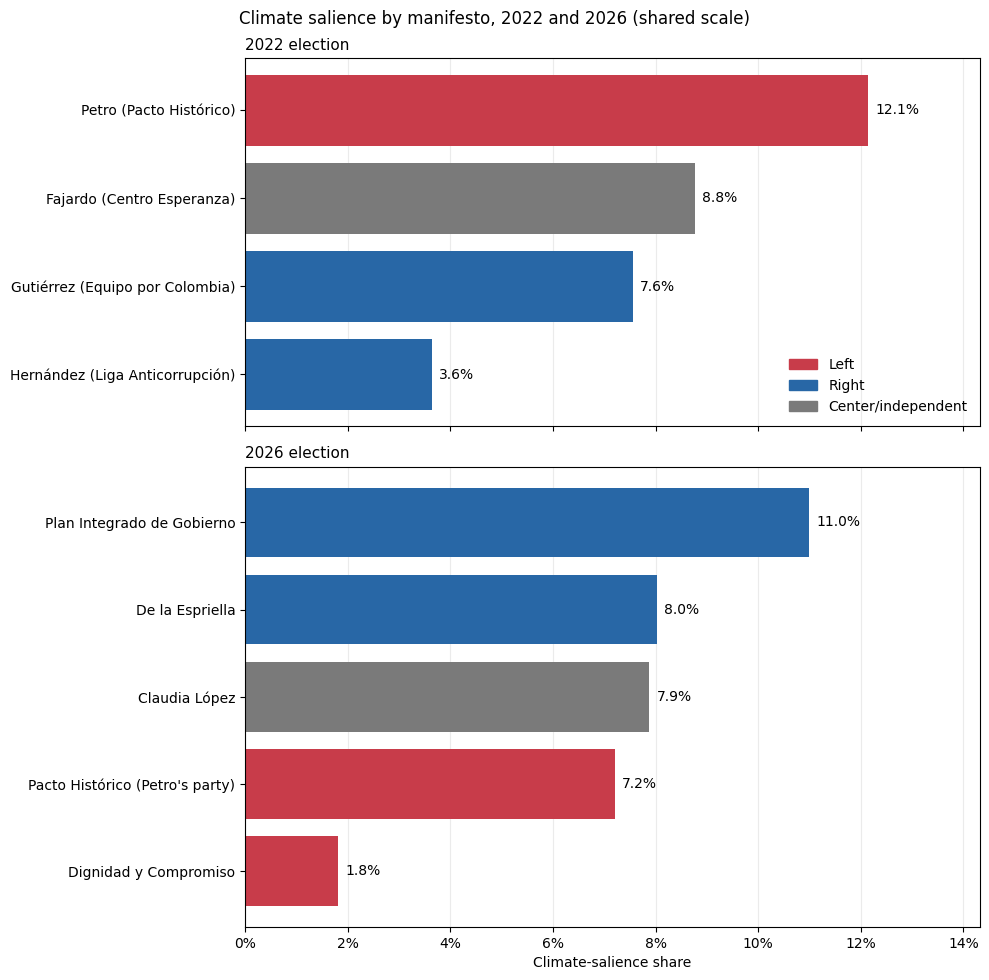

In [69]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

position_colors = {
    "Left": "#c83c4a",
    "Right": "#2867a6",
    "Center/independent": "#7a7a7a",
    "Unclassified": "#c9c9c9",
}

years_with_data = [year for year in YEARS if (summary_df["year"] == year).any()]
# One panel per year keeps the elections separate; a shared x-axis makes them comparable.
heights = [max(1, int((summary_df["year"] == year).sum())) for year in years_with_data]
fig, axes = plt.subplots(
    len(years_with_data), 1,
    figsize=(10, 1.2 + 0.75 * sum(heights) + 1.0 * len(years_with_data)),
    sharex=True,
    squeeze=False,
    gridspec_kw={"height_ratios": heights},
)
axes = axes.ravel()

x_max = float(summary_df["climate_salience_share"].max()) * 1.18
for ax, year in zip(axes, years_with_data):
    plot_df = summary_df[summary_df["year"] == year].sort_values("climate_salience_share")
    bars = ax.barh(plot_df["label"], plot_df["climate_salience_share"],
                   color=plot_df["position"].map(position_colors))
    ax.set_title(f"{year} election", loc="left", fontsize=11)
    ax.set_xlim(0, x_max)
    ax.xaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)
    for bar, value in zip(bars, plot_df["climate_salience_share"]):
        ax.text(value + x_max * 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.1%}", va="center")

axes[-1].set_xlabel("Climate-salience share")
fig.suptitle("Climate salience by manifesto, 2022 and 2026 (shared scale)")
used_positions = [p for p in position_colors if (summary_df["position"] == p).any()]
axes[0].legend(
    handles=[Patch(color=position_colors[p], label=p) for p in used_positions],
    loc="lower right",
    frameon=False,
)
fig.tight_layout()
fig.savefig(COMPARISON_DIR / "climate_salience_by_manifesto.png", dpi=200, bbox_inches="tight")
plt.show()

## Cross-year comparison: 2022 vs 2026

The two elections are scored independently above. This section is the only place the years are pooled.

Two aggregations are reported because they answer different questions:

- **pooled share** — climate-relevant sentences as a share of all sentences in that year's corpus. Dominated by the longest documents, so it describes the corpus, not the average candidate.
- **mean/median manifesto share** — the per-manifesto shares averaged, so each candidate counts once regardless of document length.

Document lengths differ by an order of magnitude within a year, so the two can move in opposite directions. Read them together, and treat shares from very short documents (a few dozen sentences) as noisy.

In [70]:
year_comparison = (
    sentences_df.groupby("year")
    .agg(
        manifestos=("manifesto_id", "nunique"),
        pdf_files=("manifesto_file", "nunique"),
        sentences=("text", "size"),
        climate_relevant_sentences=("climate_relevant", "sum"),
        pooled_climate_share=("climate_relevant", "mean"),
    )
    .join(
        summary_df.groupby("year")["climate_salience_share"].agg(
            mean_manifesto_share="mean",
            median_manifesto_share="median",
            min_manifesto_share="min",
            max_manifesto_share="max",
        )
    )
    .reset_index()
)
year_comparison.to_csv(COMPARISON_DIR / "policlim_year_comparison.csv", index=False, encoding="utf-8-sig")
print("Climate salience by election year")
display(year_comparison)

# Mean manifesto share by ideological bloc, to see whether any shift is bloc-specific.
position_comparison = summary_df.pivot_table(
    index="position", columns="year", values="climate_salience_share", aggfunc="mean"
)
position_counts = summary_df.pivot_table(
    index="position", columns="year", values="manifesto_id", aggfunc="count"
)
if position_comparison.shape[1] == 2:
    position_comparison["change"] = position_comparison[YEARS[1]] - position_comparison[YEARS[0]]
position_comparison.to_csv(COMPARISON_DIR / "policlim_position_comparison.csv", encoding="utf-8-sig")
print("\nMean manifesto-level climate salience by bloc (cell counts below)")
display(position_comparison)
display(position_counts)

Climate salience by election year


,year,manifestos,pdf_files,sentences,climate_relevant_sentences,pooled_climate_share,mean_manifesto_share,median_manifesto_share,min_manifesto_share,max_manifesto_share
0,2022,4,4,2667,219,0.082115,0.080208,0.081565,0.036329,0.121372
1,2026,5,6,2395,180,0.075157,0.071836,0.078788,0.018182,0.109848



Mean manifesto-level climate salience by bloc (cell counts below)


year,2022,2026,change
position,,,
Center/independent,0.087591,0.078788,-0.008803
Left,0.121372,0.045127,-0.076245
Right,0.055934,0.095070,0.039136


year,2022,2026
position,,
Center/independent,1,1
Left,1,2
Right,2,2


## Manual validation

Review a random sample of predictions from **both** years before using the aggregate scores substantively. The full sentence text, predicted label, per-label probability, and source manifesto are in each year's `policlim_<year>_sentence_predictions.csv`.

In [71]:
# Sample within each year so both elections are represented in the manual check.
validation_sample = (
    pd.concat([
        group.sample(min(20, len(group)), random_state=42)
        for _, group in sentences_df.groupby("year")
    ])
    [["year", "manifesto_id", "manifesto_file", "sentence_number", "text", "predicted_label", "climate_score", "label_scores"]]
    .sort_values(["year", "manifesto_id", "sentence_number"])
)
validation_sample.to_csv(COMPARISON_DIR / "policlim_validation_sample.csv", index=False, encoding="utf-8-sig")
display(validation_sample)

,year,manifesto_id,manifesto_file,sentence_number,text,predicted_label,climate_score,label_scores
2447,2022,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf,55,La propuesta completa está disponible aquí: ht...,LABEL_0,0.001151,"{""LABEL_0"": 0.998848557472229, ""LABEL_1"": 0.00..."
2560,2022,Fajardo (Centro Esperanza),resumen-propuestas-sergio-fajardo.pdf,168,El medio ambiente será el fundamento de cada i...,LABEL_0,0.000962,"{""LABEL_0"": 0.9990382194519043, ""LABEL_1"": 0.0..."
289,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,290,Trabajaremos para que Colombia pase de tener u...,LABEL_0,0.000975,"{""LABEL_0"": 0.9990247488021851, ""LABEL_1"": 0.0..."
298,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,299,La competencia también será a nivel internacio...,LABEL_0,0.001306,"{""LABEL_0"": 0.9986936450004578, ""LABEL_1"": 0.0..."
521,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,522,Incrementaremos el uso de las energías limpias...,LABEL_1,0.999411,"{""LABEL_1"": 0.9994112253189087, ""LABEL_0"": 0.0..."
532,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,533,Fortaleceremos las acciones contra el robo de ...,LABEL_1,0.999382,"{""LABEL_1"": 0.9993822574615479, ""LABEL_0"": 0.0..."
611,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,612,Realizaremos un acompañamiento permanente a lo...,LABEL_0,0.001163,"{""LABEL_0"": 0.998837411403656, ""LABEL_1"": 0.00..."
655,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,656,"Revisar los límites a la integración vertical,...",LABEL_0,0.000967,"{""LABEL_0"": 0.9990332126617432, ""LABEL_1"": 0.0..."
929,2022,Gutiérrez (Equipo por Colombia),Creemos Colombia Federico Gutiérrez.pdf,930,Mantenimiento e implementación del Estatuto Te...,LABEL_0,0.001642,"{""LABEL_0"": 0.9983575940132141, ""LABEL_1"": 0.0..."
2112,2022,Hernández (Liga Anticorrupción),RodolfoHernandez-ProgramaDeGobierno.pdf,243,El faltante será asumido por el Estado.,LABEL_0,0.000948,"{""LABEL_0"": 0.9990519881248474, ""LABEL_1"": 0.0..."


## Abelardo de la Espriella (2026 only)

De la Espriella stood in 2026 but not in 2022, so his rank and percentile are computed **within the 2026 field only**. Comparing him against a pooled 2022+2026 field would mix two different candidate sets.

His programme is distributed as more than one PDF. Those files were merged into a single document in the extraction cell, so the share below is computed over the combined text; the constituent filenames are printed under `source_files`.


In [72]:
# De la Espriella's programme arrives as several PDFs, already merged into one document
# by the extraction cell. Ranking is within 2026 only: he did not stand in 2022, so a
# pooled rank would be meaningless.
summary_2026 = summary_df[summary_df["year"] == "2026"]
abelardo_matches = summary_2026[
    summary_2026["manifesto_id"].str.contains("abelardo|espriella|tigre", case=False, na=False)
].copy()
if len(abelardo_matches) != 1:
    raise ValueError(
        "Expected one merged De la Espriella manifesto, found: "
        f"{abelardo_matches['manifesto_id'].tolist()}"
    )

abelardo_id = abelardo_matches.iloc[0]["manifesto_id"]
comparison = summary_2026[["manifesto_id", "label", "source_documents", "climate_salience_share", "sentence_count"]].copy()
comparison["rank"] = comparison["climate_salience_share"].rank(method="min", ascending=False).astype(int)
comparison["percentile"] = comparison["climate_salience_share"].rank(pct=True) * 100
abelardo_row = comparison[comparison["manifesto_id"] == abelardo_id].iloc[0]

print(f"Manifesto: {abelardo_id}")
print(f"Assembled from {int(abelardo_row['source_documents'])} PDF(s): {abelardo_matches.iloc[0]['source_files']}")
print(f"Climate-salience share: {abelardo_row['climate_salience_share']:.1%}")
print(f"Rank: {int(abelardo_row['rank'])} of {len(comparison)} 2026 manifestos")
print(f"Percentile: {abelardo_row['percentile']:.1f}")
print(f"Based on {int(abelardo_row['sentence_count'])} extracted sentences")
display(comparison.sort_values("climate_salience_share", ascending=False))


Manifesto: De la Espriella
Assembled from 2 PDF(s): PROPUESTAS_de_la_Espriella.pdf; Programa_de_gobierno_Abelardo_de_la_Espriella_2026_2030-1.pdf
Climate-salience share: 8.0%
Rank: 2 of 5 2026 manifestos
Percentile: 80.0
Based on 137 extracted sentences


,manifesto_id,label,source_documents,climate_salience_share,sentence_count,rank,percentile
8,Plan Integrado de Gobierno,Plan Integrado de Gobierno,1,0.109848,264,1,100.0
5,De la Espriella,De la Espriella,2,0.080292,137,2,80.0
4,Claudia López,Claudia López,1,0.078788,330,3,60.0
7,Pacto Histórico (Petro's party),Pacto Histórico (Petro's party),1,0.072072,1554,4,40.0
6,Dignidad y Compromiso,Dignidad y Compromiso,1,0.018182,110,5,20.0


Interpretation

The share printed above is the fraction of extracted sentences that `policlim` classified as climate-relevant, ranked against the other 2026 manifestos only.

Three caveats apply to every number in this notebook:

- It is a **salience** measure — how much climate is talked about — not a measure of ambition, direction, or quality. A manifesto that argues for expanding coal and gas scores as climate-relevant in the same way as one arguing for phasing them out.
- Shares from short documents are unstable. Where a manifesto yields only a few dozen sentences, a handful of classifications moves the share by several percentage points.
- Sentence counts reflect PDF text extraction, not the documents' true length. Scanned or heavily formatted PDFs under-extract, and any file that produced no text is flagged in the extraction cell.

In [73]:
# Highest-scoring sentences in the top-ranked manifesto of each year.
for year in years_with_data:
    year_summary = summary_df[summary_df["year"] == year]
    top_row = year_summary.sort_values("climate_salience_share", ascending=False).iloc[0]
    top_sentences = (
        sentences_df[(sentences_df["year"] == year) & (sentences_df["manifesto_id"] == top_row["manifesto_id"])]
        .sort_values(["climate_score", "sentence_number"], ascending=[False, True])
        .head(5)
    )
    print(f"\n===== {year}: rank 1 = {top_row['label']} ({top_row['source_files']}) =====")
    print(f"Climate-salience share: {top_row['climate_salience_share']:.1%} "
          f"of {int(top_row['sentence_count'])} sentences")
    for _, row in top_sentences.iterrows():
        print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")


===== 2022: rank 1 = Petro (Pacto Histórico) (Programa-de-gobierno-Gustavo-Petro-2022-–-2026.pdf) =====
Climate-salience share: 12.1% of 758 sentences

[100.0%] Sentence 174:
Hacia una sociedad movida por el sol, el viento y el agua Haremos que Colombia transite de una matriz energética primaria, predominante- mente fósil, dependiente económicamente del carbón y del petróleo, hacia una diver- sificada, basada en nuestras potenciali- dades de energías renovables, las cuales son las mejores fuentes energéticas para enfrentar el cambio climático y fortalecer las capacidades del país para la econo- mía productiva.

[100.0%] Sentence 198:
Se impulsará la sustitución de las plantas termoeléctricas por sistemas de almace- namiento o fuentes renovables y se forta- lecerá el rol del estado en el despacho de energía eléctrica, con el fin de garantizar la confiabilidad y estabilidad del sistema eléctrico del país asociados a la variabili- dad y el cambio climático.

[99.9%] Sentence 204:
La extr

In [74]:
# Fifteen De la Espriella sentences (across all his merged PDFs) with the highest
# model probability for the climate-relevant label.
abelardo_sentences = sentences_df[
    (sentences_df["year"] == "2026") & (sentences_df["manifesto_id"] == abelardo_id)
].copy()
top_sentences = abelardo_sentences.sort_values(
    ["climate_score", "sentence_number"], ascending=[False, True]
).head(25)
for _, row in top_sentences.iterrows():
    print(f"\n[{row['climate_score']:.1%}] Sentence {int(row['sentence_number'])}:\n{row['text']}")


[99.9%] Sentence 18:
8 LA POLÍTICA MINERO ENERGÉTICA DE LA PATRIA MILAGRO * Argumento central: Colombia no puede seguir tratando el sector minero-energético con prejuicios ideológicos ni improvisación, porque de él dependen la seguridad energética, la competitividad, el empleo, la estabilidad ﬁscal y una parte decisiva de la inversión regional y social.

[99.9%] Sentence 19:
El problema no es la falta de recursos, sino la falta de decisiones serias para convertirlos en seguridad energética y ﬁscal. * Propuestas clave: ▪ Recuperar la exploración y la producción de petróleo y gas con seguridad jurídica y criterio técnico. ▪ Fortalecer la autosuﬁciencia energética. ▪ Tratar el gas como asunto estratégico acelerando campos descubiertos, proyectos costa afuera, transporte e infraestructura, y evaluando con rigor los yacimientos no convencionales. ▪ Transformar el sistema eléctrico de la Costa Caribe. ▪ Defender a Ecopetrol como activo estratégico de la Nación. ▪ Desarrollar con sentido de 

## Petro / Pacto Histórico, 2022 vs 2026: is the drop a document-length effect?

The Pacto Histórico is the only competitor with a manifesto in both years, so it is the only within-party comparison available. Its climate-salience share falls from about 12% (2022) to about 7% (2026). The two documents have different authors — Petro's own programme in 2022, Iván Cepeda's in 2026 — so the comparison is party-level, not candidate-level.

A share is a ratio, so it can fall for two different reasons:

- **numerator** — the manifesto contains less climate text in absolute terms;
- **denominator** — the manifesto grew, and the added text is about something else, diluting a roughly constant amount of climate text.

The cells below separate the two, then check whether the result survives three robustness tests (word-based normalisation, a minimum sentence length filter, and equal-length subsamples of the 2026 document). The last cells report which climate keywords appear in 2022 but no longer in 2026.

In [75]:
import numpy as np

# Both documents carry "Pacto Histórico" in their display label, so one pattern finds
# the pair without hard-coding filenames that may change in the repository.
petro_summary = summary_df[summary_df["label"].str.contains("Pacto Hist", case=False, na=False)]
if set(petro_summary["year"]) != {"2022", "2026"}:
    raise ValueError(f"Expected one Pacto Histórico manifesto per year, found:\n{petro_summary[['year', 'manifesto_id', 'label']]}")

PETRO_IDS = dict(zip(petro_summary["year"], petro_summary["manifesto_id"]))
print("Documents compared:")
for year, row in petro_summary.set_index("year").sort_index().iterrows():
    print(f"  {year}: {row['manifesto_id']} <- {row['source_files']}")

petro_sentences = sentences_df[
    [(year, name) in {(y, m) for y, m in PETRO_IDS.items()}
     for year, name in zip(sentences_df["year"], sentences_df["manifesto_id"])]
].copy()
petro_sentences["word_count"] = petro_sentences["text"].str.split().str.len()

# Word-based measures are reported alongside sentence-based ones because sentence
# counts depend on how the splitter cuts each PDF, while word counts do not.
petro_profile = (
    petro_sentences.groupby("year")
    .apply(lambda g: pd.Series({
        "sentences": len(g),
        "words": int(g["word_count"].sum()),
        "median_words_per_sentence": float(g["word_count"].median()),
        "climate_sentences": int(g["climate_relevant"].sum()),
        "climate_words": int(g.loc[g["climate_relevant"], "word_count"].sum()),
        "climate_share_of_sentences": float(g["climate_relevant"].mean()),
        "climate_share_of_words": float(g.loc[g["climate_relevant"], "word_count"].sum() / g["word_count"].sum()),
        "climate_sentences_per_10k_words": float(g["climate_relevant"].sum() / g["word_count"].sum() * 10_000),
    }), include_groups=False)
)
print("\nPetro / Pacto Histórico manifesto profile")
display(petro_profile)

n22, n26 = petro_profile.loc["2022", "sentences"], petro_profile.loc["2026", "sentences"]
c22, c26 = petro_profile.loc["2022", "climate_sentences"], petro_profile.loc["2026", "climate_sentences"]
share22, share26 = c22 / n22, c26 / n26

# Multiplicative decomposition: log(share26/share22) = log(c26/c22) - log(n26/n22),
# so the two channels add up exactly and their relative weights are readable.
log_total = np.log(share26 / share22)
log_numerator = np.log(c26 / c22)
log_denominator = -np.log(n26 / n22)

print(f"\n2022: {c22:,.0f} climate sentences / {n22:,.0f} sentences = {share22:.1%}")
print(f"2026: {c26:,.0f} climate sentences / {n26:,.0f} sentences = {share26:.1%}")
print(f"\nClimate sentences (numerator):  x{c26 / c22:.2f}")
print(f"Total sentences (denominator):  x{n26 / n22:.2f}")
print(f"Contribution to the fall in the share:")
print(f"  document growth (denominator): {log_denominator / log_total:6.1%}")
print(f"  less climate text (numerator): {log_numerator / log_total:6.1%}")

print(f"\nCounterfactual shares:")
print(f"  2026 climate sentences over 2022 document length: {c26 / n22:.1%}")
print(f"  2022 climate sentences over 2026 document length: {c22 / n26:.1%}")

Documents compared:
  2022: Petro (Pacto Histórico) <- Programa-de-gobierno-Gustavo-Petro-2022-–-2026.pdf
  2026: Pacto Histórico (Petro's party) <- programa-gobierno-2026-2030_cepeda.pdf

Petro / Pacto Histórico manifesto profile


,sentences,words,median_words_per_sentence,climate_sentences,climate_words,climate_share_of_sentences,climate_share_of_words,climate_sentences_per_10k_words
year,,,,,,,,
2022,758.0,28744.0,33.0,92.0,4068.0,0.121372,0.141525,32.006680
2026,1554.0,53388.0,33.0,112.0,4405.0,0.072072,0.082509,20.978497



2022: 92 climate sentences / 758 sentences = 12.1%
2026: 112 climate sentences / 1,554 sentences = 7.2%

Climate sentences (numerator):  x1.22
Total sentences (denominator):  x2.05
Contribution to the fall in the share:
  document growth (denominator): 137.7%
  less climate text (numerator): -37.7%

Counterfactual shares:
  2026 climate sentences over 2022 document length: 14.8%
  2022 climate sentences over 2026 document length: 5.9%


In [76]:
# Three checks that the gap is not an artefact of how the longer 2026 PDF was split.
MIN_WORDS = 8
DRAWS = 2000

rows = []
for year in ["2022", "2026"]:
    doc = petro_sentences[petro_sentences["year"] == year]
    long_only = doc[doc["word_count"] >= MIN_WORDS]
    rows.append({
        "year": year,
        "all sentences": doc["climate_relevant"].mean(),
        f"sentences >= {MIN_WORDS} words": long_only["climate_relevant"].mean(),
        "climate words / all words": doc.loc[doc["climate_relevant"], "word_count"].sum() / doc["word_count"].sum(),
    })
robustness = pd.DataFrame(rows).set_index("year")
robustness.loc["ratio 2026/2022"] = robustness.loc["2026"] / robustness.loc["2022"]
print(f"Climate salience under three normalisations (short sentences are mostly headings and list items)")
display(robustness.style.format("{:.1%}"))

# Equal-length subsamples: if the 2026 share only looked low because the document is
# long, drawing 2022-sized subsamples from it would recover the 2022 level.
doc26 = petro_sentences[petro_sentences["year"] == "2026"]["climate_relevant"].to_numpy()
rng = np.random.default_rng(42)
subsample_shares = np.array([
    rng.choice(doc26, size=int(n22), replace=False).mean() for _ in range(DRAWS)
])
print(f"\n{DRAWS} random {int(n22)}-sentence subsamples of the 2026 document")
print(f"  mean share: {subsample_shares.mean():.1%}  "
      f"(95% range {np.percentile(subsample_shares, 2.5):.1%} - {np.percentile(subsample_shares, 97.5):.1%})")
print(f"  2022 share for the same document length: {share22:.1%}")
print(f"  subsamples reaching the 2022 share: {(subsample_shares >= share22).mean():.1%}")

# Consecutive blocks: the climate content of the 2026 document could sit in one
# chapter, in which case its densest 2022-sized stretch is the fair comparison.
block_size = int(n22)
blocks = [doc26[start:start + block_size] for start in range(0, len(doc26), block_size)]
block_table = pd.DataFrame({
    "block": [f"sentences {i * block_size + 1}-{min((i + 1) * block_size, len(doc26))}" for i in range(len(blocks))],
    "sentences": [len(b) for b in blocks],
    "climate_sentences": [int(b.sum()) for b in blocks],
    "climate_share": [float(b.mean()) for b in blocks],
})
print(f"\n2026 document split into consecutive {block_size}-sentence blocks (2022 document length)")
display(block_table)
print(f"Densest block: {block_table['climate_share'].max():.1%} vs 2022 whole-document {share22:.1%}")

robustness.to_csv(COMPARISON_DIR / "petro_2022_vs_2026_length_robustness.csv", encoding="utf-8-sig")
block_table.to_csv(COMPARISON_DIR / "petro_2026_block_shares.csv", index=False, encoding="utf-8-sig")

Climate salience under three normalisations (short sentences are mostly headings and list items)


,all sentences,sentences >= 8 words,climate words / all words
year,,,
2022,12.1%,12.3%,14.2%
2026,7.2%,7.3%,8.3%
ratio 2026/2022,59.4%,59.3%,58.3%



2000 random 758-sentence subsamples of the 2026 document
  mean share: 7.2%  (95% range 5.9% - 8.4%)
  2022 share for the same document length: 12.1%
  subsamples reaching the 2022 share: 0.0%

2026 document split into consecutive 758-sentence blocks (2022 document length)


,block,sentences,climate_sentences,climate_share
0,sentences 1-758,758,24,0.031662
1,sentences 759-1516,758,88,0.116095
2,sentences 1517-1554,38,0,0.000000


Densest block: 11.6% vs 2022 whole-document 12.1%


### Which climate vocabulary disappeared?

The classifier gives a share but not the content behind it. Two complementary keyword counts follow.

The first is a fixed Spanish climate and energy lexicon applied to the full text of each document, so both years are measured against the same list. Counts are reported per 10,000 words as well as raw, because the 2026 document is several times longer: a term can appear more often in absolute terms and still be rarer per page.

The second is data-driven — terms that occur in the sentences `policlim` flagged as climate-relevant in 2022 and never in the 2026 flagged sentences. It is not restricted to a predefined list, so it also picks up policy-specific wording.

Text is de-hyphenated and accent-stripped before matching, because PDF extraction breaks words across lines ("climáti- co") and sometimes drops accents.

In [77]:
def normalise_for_matching(text):
    """Lowercase, repair PDF hyphenation, and strip accents so patterns need one spelling."""
    text = re.sub(r"(\w)-\s+(\w)", r"\1\2", text.lower())
    text = "".join(ch for ch in unicodedata.normalize("NFKD", text) if not unicodedata.combining(ch))
    return re.sub(r"\s+", " ", text)


# Accents are stripped before matching, so "carbon" (coal) and "carbono" (carbon) are
# kept apart by word boundaries rather than by the accent.
CLIMATE_LEXICON = {
    "cambio climático": r"cambio\s+climatic\w*",
    "crisis/emergencia climática": r"(crisis|emergencia)\s+climatic\w*",
    "climático (cualquier uso)": r"climatic\w*",
    "calentamiento global": r"calentamiento\s+global",
    "efecto invernadero / GEI": r"efecto\s+invernadero|\bgei\b|gases\s+de\s+efecto",
    "descarbonización": r"descarboniz\w*",
    "transición energética": r"transicion\w*\s+energetic\w*",
    "transición justa": r"transicion\s+justa",
    "energías renovables": r"energias?\s+renovables?|fuentes?\s+renovables?",
    "energías limpias": r"energias?\s+limpias?",
    "solar / fotovoltaica": r"energia\s+solar|fotovoltaic\w*|paneles?\s+solares?",
    "eólica": r"eolic\w*",
    "hidrógeno verde": r"hidrogeno\s+verde",
    "geotérmica": r"geotermic\w*",
    "biomasa": r"\bbiomasa\b",
    "biocombustibles": r"biocombustible\w*",
    "hidroeléctrica": r"hidroelectric\w*",
    "nuclear": r"\bnuclear\w*",
    "combustibles fósiles": r"combustibles?\s+fosiles?|\bfosil\w*",
    "petróleo": r"petrole\w*",
    "carbón (mineral)": r"\bcarbon\b|\bcarbones\b",
    "gas natural": r"gas\s+natural|\bgasoduct\w*",
    "fracking / no convencionales": r"\bfracking\b|fractura\w*\s+hidraulic\w*|yacimientos?\s+no\s+convencionales?",
    "extractivismo": r"extractiv\w*",
    "minería": r"\bmineri\w*|\bminera\w*",
    "neutralidad de carbono / cero neto": r"neutralidad\s+(de\s+)?carbono|carbono\s+neutral\w*|cero\s+neto|net\s+zero",
    "huella de carbono": r"huella\w*\s+de\s+carbono",
    "mercados/bonos de carbono": r"(bonos?|mercados?|creditos?)\s+de\s+carbono",
    "impuesto al carbono": r"impuesto\w*\s+al\s+carbono",
    "captura/sumideros de carbono": r"captura\w*\s+de\s+carbono|sumideros?\s+de\s+carbono",
    "mitigación": r"mitigacion\w*|mitigar",
    "adaptación": r"adaptacion\w*|adaptarse",
    "resiliencia": r"resilien\w*",
    "Acuerdo de París": r"acuerdo\s+de\s+paris",
    "COP / NDC": r"\bcop\s?\d+\b|\bndc\b|contribucion\w*\s+determinada\w*",
    "deforestación": r"deforest\w*",
    "reforestación / restauración": r"reforestacion\w*|restauracion\s+ecologic\w*|restaurar\s+ecosistemas",
    "páramos": r"\bparamos?\b",
    "Amazonía": r"amazon\w*",
    "biodiversidad": r"biodiversidad",
    "áreas protegidas": r"areas?\s+protegidas?|parques?\s+naturales?",
    "economía circular": r"economia\s+circular",
    "movilidad eléctrica": r"movilidad\s+electrica|vehiculos?\s+electricos?|electromovilidad",
    "justicia climática/ambiental": r"justicia\s+(climatic|ambiental)\w*",
    "crisis ambiental/ecológica": r"crisis\s+(ambiental|ecologic\w*)",
    "sequía / desertificación": r"sequia\w*|desertificacion\w*",
    "inundaciones": r"inundacion\w*",
    "gestión del riesgo de desastres": r"gestion\s+del\s+riesgo|riesgo\w*\s+de\s+desastre\w*",
    "ambiental (cualquier uso)": r"ambiental\w*|medio\s+ambiente",
}

doc_text = {
    year: normalise_for_matching(" ".join(group["text"]))
    for year, group in petro_sentences.groupby("year")
}
doc_words = {year: int(petro_profile.loc[year, "words"]) for year in doc_text}

keyword_rows = []
for term, pattern in CLIMATE_LEXICON.items():
    counts = {year: len(re.findall(pattern, text)) for year, text in doc_text.items()}
    keyword_rows.append({
        "term": term,
        "count_2022": counts["2022"],
        "count_2026": counts["2026"],
        "per_10k_2022": counts["2022"] / doc_words["2022"] * 10_000,
        "per_10k_2026": counts["2026"] / doc_words["2026"] * 10_000,
    })

keyword_df = pd.DataFrame(keyword_rows)
keyword_df["per_10k_change"] = keyword_df["per_10k_2026"] - keyword_df["per_10k_2022"]
keyword_df = keyword_df.sort_values("per_10k_2022", ascending=False).reset_index(drop=True)
keyword_df.to_csv(COMPARISON_DIR / "petro_climate_keyword_comparison.csv", index=False, encoding="utf-8-sig")

pd.set_option("display.max_rows", 200)
print(f"Document length: {doc_words['2022']:,} words (2022) vs {doc_words['2026']:,} words (2026)")
print("\nClimate lexicon, full manifesto text, raw counts and rates per 10,000 words")
display(keyword_df.style.format({"per_10k_2022": "{:.1f}", "per_10k_2026": "{:.1f}", "per_10k_change": "{:+.1f}"}))

gone = keyword_df[(keyword_df["count_2022"] > 0) & (keyword_df["count_2026"] == 0)]
print(f"\nPresent in 2022, absent in 2026 ({len(gone)} terms)")
display(gone[["term", "count_2022", "per_10k_2022"]].style.format({"per_10k_2022": "{:.1f}"}))

new = keyword_df[(keyword_df["count_2022"] == 0) & (keyword_df["count_2026"] > 0)]
print(f"\nAbsent in 2022, present in 2026 ({len(new)} terms)")
display(new[["term", "count_2026", "per_10k_2026"]].style.format({"per_10k_2026": "{:.1f}"}))

print("\nLargest declines in rate per 10,000 words")
display(
    keyword_df.nsmallest(15, "per_10k_change")[["term", "count_2022", "count_2026", "per_10k_2022", "per_10k_2026", "per_10k_change"]]
    .style.format({"per_10k_2022": "{:.1f}", "per_10k_2026": "{:.1f}", "per_10k_change": "{:+.1f}"})
)

Document length: 28,744 words (2022) vs 53,388 words (2026)

Climate lexicon, full manifesto text, raw counts and rates per 10,000 words


,term,count_2022,count_2026,per_10k_2022,per_10k_2026,per_10k_change
0,ambiental (cualquier uso),43,77,15.0,14.4,-0.5
1,climático (cualquier uso),37,44,12.9,8.2,-4.6
2,cambio climático,31,8,10.8,1.5,-9.3
3,minería,14,13,4.9,2.4,-2.4
4,transición energética,9,25,3.1,4.7,+1.6
5,biodiversidad,9,32,3.1,6.0,+2.9
6,carbón (mineral),8,2,2.8,0.4,-2.4
7,extractivismo,8,13,2.8,2.4,-0.3
8,combustibles fósiles,7,4,2.4,0.7,-1.7
9,Amazonía,6,11,2.1,2.1,-0.0



Present in 2022, absent in 2026 (5 terms)


,term,count_2022,per_10k_2022
14,hidroeléctrica,3,1.0
16,descarbonización,3,1.0
24,solar / fotovoltaica,2,0.7
25,hidrógeno verde,2,0.7
26,movilidad eléctrica,2,0.7



Absent in 2022, present in 2026 (2 terms)


,term,count_2026,per_10k_2026
35,efecto invernadero / GEI,1,0.2
48,inundaciones,1,0.2



Largest declines in rate per 10,000 words


,term,count_2022,count_2026,per_10k_2022,per_10k_2026,per_10k_change
2,cambio climático,31,8,10.8,1.5,-9.3
1,climático (cualquier uso),37,44,12.9,8.2,-4.6
3,minería,14,13,4.9,2.4,-2.4
6,carbón (mineral),8,2,2.8,0.4,-2.4
10,petróleo,6,1,2.1,0.2,-1.9
8,combustibles fósiles,7,4,2.4,0.7,-1.7
14,hidroeléctrica,3,0,1.0,0.0,-1.0
16,descarbonización,3,0,1.0,0.0,-1.0
11,energías limpias,6,6,2.1,1.1,-1.0
13,adaptación,4,3,1.4,0.6,-0.8


In [78]:
from collections import Counter

# Data-driven counterpart to the fixed lexicon: vocabulary of the sentences the model
# itself flagged as climate-relevant, so nothing depends on the list above.
SPANISH_STOPWORDS = {
    "para", "como", "esta", "este", "esto", "estos", "estas", "sobre", "entre", "desde", "hasta",
    "donde", "cuando", "porque", "pero", "todos", "todas", "todo", "toda", "otros", "otras",
    "cada", "sera", "seran", "hacer", "haremos", "vamos", "debe", "deben", "puede", "pueden",
    "mismo", "misma", "tambien", "asi", "mas", "menos", "muy", "sino", "sean", "ellos", "ellas",
    "nuestro", "nuestra", "nuestros", "nuestras", "colombia", "colombiano", "colombianos",
    "colombiana", "colombianas", "pais", "nacional", "nacionales", "gobierno", "publico",
    "publica", "publicos", "publicas", "estado", "sistema", "politica", "politicas", "social",
    "sociales", "desarrollo", "programa", "plan", "proceso", "gran", "nueva", "nuevo", "nuevos",
    "nuevas", "traves", "partir", "manera", "forma", "parte", "trata", "ser", "han", "hay",
}

def content_tokens(texts):
    tokens = re.findall(r"[a-z]{4,}", normalise_for_matching(" ".join(texts)))
    return [token for token in tokens if token not in SPANISH_STOPWORDS]


climate_tokens = {}
climate_bigrams = {}
for year in ["2022", "2026"]:
    flagged = petro_sentences[(petro_sentences["year"] == year) & petro_sentences["climate_relevant"]]["text"]
    tokens = content_tokens(flagged)
    climate_tokens[year] = Counter(tokens)
    # Bigrams are formed after stopword removal, so "lucha contra el cambio"
    # is counted as "contra cambio".
    climate_bigrams[year] = Counter(zip(tokens, tokens[1:]))
    print(f"{year}: {len(flagged)} climate-flagged sentences, {len(tokens):,} content tokens")

MIN_2022_COUNT = 3
lost_terms = pd.DataFrame(
    [{"term": term, "count_2022": count, "count_2026": climate_tokens["2026"][term]}
     for term, count in climate_tokens["2022"].most_common()
     if count >= MIN_2022_COUNT and climate_tokens["2026"][term] == 0]
)
print(f"\nWords used at least {MIN_2022_COUNT} times in 2022 climate-flagged sentences and never in 2026 ({len(lost_terms)} terms)")
display(lost_terms)

lost_bigrams = pd.DataFrame(
    [{"bigram": " ".join(bigram), "count_2022": count}
     for bigram, count in climate_bigrams["2022"].most_common()
     if count >= 2 and climate_bigrams["2026"][bigram] == 0]
)
print(f"\nTwo-word phrases used at least twice in 2022 climate-flagged sentences and never in 2026 ({len(lost_bigrams)} phrases)")
display(lost_bigrams.head(40))

# The reverse direction shows what replaced them.
gained_terms = pd.DataFrame(
    [{"term": term, "count_2026": count, "count_2022": climate_tokens["2022"][term]}
     for term, count in climate_tokens["2026"].most_common()
     if count >= MIN_2022_COUNT and climate_tokens["2022"][term] == 0]
)
print(f"\nWords used at least {MIN_2022_COUNT} times in 2026 climate-flagged sentences and never in 2022 ({len(gained_terms)} terms)")
display(gained_terms)

lost_terms.to_csv(COMPARISON_DIR / "petro_climate_terms_lost_2026.csv", index=False, encoding="utf-8-sig")
lost_bigrams.to_csv(COMPARISON_DIR / "petro_climate_bigrams_lost_2026.csv", index=False, encoding="utf-8-sig")
gained_terms.to_csv(COMPARISON_DIR / "petro_climate_terms_new_2026.csv", index=False, encoding="utf-8-sig")

2022: 92 climate-flagged sentences, 1,886 content tokens
2026: 112 climate-flagged sentences, 2,252 content tokens

Words used at least 3 times in 2022 climate-flagged sentences and never in 2026 (37 terms)


,term,count_2022,count_2026
0,reservas,5,0
1,permita,4,0
2,vital,4,0
3,mundo,4,0
4,carbono,4,0
5,popular,4,0
6,tributarios,4,0
7,avanzara,4,0
8,lider,3,0
9,tipo,3,0



Two-word phrases used at least twice in 2022 climate-flagged sentences and never in 2026 (73 phrases)


,bigram,count_2022
0,economia productiva,9
1,agenda internacional,6
2,internacional lucha,4
3,adaptacion cambio,4
4,carbon petroleo,4
5,economia popular,4
6,minimo vital,3
7,hacia economia,3
8,lider lucha,2
9,climatico promocion,2



Words used at least 3 times in 2026 climate-flagged sentences and never in 2022 (55 terms)


,term,count_2026,count_2022
0,revolucion,11,0
1,asimismo,9,0
2,innovacion,7,0
3,estrategicos,7,0
4,consolidando,7,0
5,especialmente,6,0
6,bioeconomia,5,0
7,soberana,5,0
8,defensa,5,0
9,vias,5,0


### Reading the result

The fall is a denominator effect, but not one that leaves the numerator fixed. Climate-relevant sentences rise — 92 in 2022, 112 in 2026 (x1.22) — while the document roughly doubles: 758 to 1,554 sentences (x2.05), 29k to 53k words. The share therefore falls from 12.1% to 7.2%. In the log decomposition, document growth accounts for 138% of the fall and the numerator works against it by -38%: the party added climate text, but added everything else about twice as fast.

"Driven by length" is not the same as "no real change". Climate content is diluted on every normalisation: 12.3% against 7.3% once sentences under eight words (mostly headings and list items) are dropped, 14.2% against 8.3% measured in words rather than sentences, and 32 against 21 climate sentences per 10,000 words. None of 2,000 random 758-sentence subsamples of the 2026 document reaches the 2022 share (mean 7.2%, 95% range 5.9-8.4%).

The 2026 document is internally uneven, however. Split into consecutive blocks of the 2022 document's length, the first 758 sentences score 3.2% and the next 758 score 11.6% — close to the 2022 whole-document 12.1%. Climate content sits in the later part of the programme, so any comparison drawn from an excerpt depends on which part is read.

One extraction detail matters for the keyword tables. The 2026 PDF stores its text as Latin-1 bytes while declaring Adobe StandardEncoding, so accented characters arrive as unrelated glyphs ("climática" as "climÆtica"). `repair_encoding` in the extraction cell undoes the substitutions; without it, accent stripping cannot normalise them, *cambio climático* counts as absent in 2026, and the data-driven vocabulary list fills with fragments (*clim*, *tica*, *energ*).

With that repaired, the counts show a change of vocabulary rather than an exit from the topic:

- Climate framing moves from change to crisis: *cambio climático* 31 to 8, *crisis/emergencia climática* 2 to 17, *justicia climática/ambiental* 1 to 9. Summed over any use, *climático* rises in raw counts (37 to 44) and falls per page (12.9 to 8.2 per 10,000 words).
- Fossil and mining vocabulary falls in raw counts as well as per page: *carbón* 8 to 2, *petróleo* 6 to 1, *combustibles fósiles* 7 to 4, *minería* 14 to 13 (4.9 to 2.4 per 10,000 words). Five terms disappear altogether: *descarbonización*, *hidroeléctrica*, *solar/fotovoltaica*, *hidrógeno verde* and *movilidad eléctrica*.
- Named technologies give way to system-level and biodiversity language: *transición energética* 9 to 25, *biodiversidad* 9 to 32, *deforestación* 3 to 9, *resiliencia* 1 to 7. *Amazonía* rises 6 to 11 but is flat per page (2.1 in both years).

Two qualifications. The 2026 programme is Cepeda's and the 2022 one Petro's, and they differ in genre as well as authorship, so sentence and word shares measure what a reader encounters without holding document type constant. And differences resting on one to three mentions (*biomasa*, *páramos*, *efecto invernadero*) are fragile: a single sentence moves them.